In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from ultralytics import YOLO
from PIL import Image
from transformers import CLIPProcessor, CLIPVisionModelWithProjection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "mps"
print(f"Using device: {device}")

Using device: mps


In [3]:
raw_dataset = load_dataset("jojogo9/freshness_of_fruits_and_veges_256")
original_labels = raw_dataset['train'].features['label'].names
target_class_names = ['FreshApple', 'RottenApple', 'FreshBanana', 'RottenBanana', 'FreshOrange', 'RottenOrange']

target_original_ids = [original_labels.index(name) for name in target_class_names]
id_mapping = {old_id: new_id for new_id, old_id in enumerate(target_original_ids)}

remapped_dataset = raw_dataset.filter(lambda x: x['label'] in target_original_ids)
remapped_dataset = remapped_dataset.map(lambda x: {'label': id_mapping[x['label']]})
labels = target_class_names
num_classes = len(labels)

Filter:   0%|          | 0/5576 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [4]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

class CLIPFreshnessSpecialist(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.clip = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
        for param in self.clip.parameters():
            param.requires_grad = False
        self.mlp = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, pixel_values):
        with torch.no_grad():
            clip_outputs = self.clip(pixel_values=pixel_values)
            image_embeds = clip_outputs.image_embeds
        return self.mlp(image_embeds)

model = CLIPFreshnessSpecialist(num_classes).to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.

In [6]:
def clip_transform_fn(examples):
    inputs = processor(images=[img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    examples["pixel_values"] = inputs["pixel_values"]
    del examples["image"]
    return examples

transformed_ds = remapped_dataset.with_transform(clip_transform_fn)
train_loader = DataLoader(transformed_ds['train'], batch_size=32, shuffle=True)

optimizer = optim.Adam(model.mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def train_clip_specialist(epochs=5):
    print(f"Training CLIP-MLP for {epochs} epochs...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            inputs, targets = batch["pixel_values"].to(device), batch["label"].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss / len(train_loader):.4f}")
    torch.save(model.state_dict(), "clip_freshness_pantry.pth")

In [7]:
yolo_model = YOLO('yolov8n.pt') 

def run_pantry_inventory(image_path):
    # Detect objects with YOLO
    results = yolo_model(image_path, conf=0.25) # Lower confidence to catch "sandwiches"
    img = Image.open(image_path).convert("RGB")
    
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(img)
    model.eval()
    
    # Inventory Counters
    inventory = {name: 0 for name in labels}
    total_detected = 0
    
    # Mapping COCO IDs to Specialist Classes
    # 47: Apple, 46: Banana, 49: Orange, 48: Sandwich (Handled as Apple)
    valid_indices = {
        47: [0, 1], 46: [2, 3], 49: [4, 5], 48: [0, 1] 
    }
    
    with torch.no_grad():
        for r in results:
            for box in r.boxes:
                yolo_cls = int(box.cls)
                
                if yolo_cls in valid_indices:
                    total_detected += 1
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    
                    # Crop and Pad
                    pad = 20
                    w, h = img.size
                    crop = img.crop((max(0, x1-pad), max(0, y1-pad), min(w, x2+pad), min(h, y2+pad)))
                    
                    # Classify with CLIP-MLP
                    inputs = processor(images=crop, return_tensors="pt").to(device)
                    logits = model(inputs.pixel_values)
                    
                    allowed_idx = valid_indices[yolo_cls]
                    filtered_logits = logits[0, allowed_idx]
                    probs = F.softmax(filtered_logits, dim=0)
                    
                    best_local_idx = torch.argmax(filtered_logits).item()
                    final_class_idx = allowed_idx[best_local_idx]
                    
                    res_label = labels[final_class_idx]
                    conf = probs[best_local_idx].item()
                    
                    # Update Inventory
                    inventory[res_label] += 1
                    
                    # Visual Output
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='cyan', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1-10, f"{res_label} ({conf*100:.1f}%)", 
                            color='black', fontsize=10, bbox=dict(facecolor='cyan', alpha=0.8))

    # Add Summary Dashboard
    summary_text = f"PANTRY INVENTORY\nTotal Items: {total_detected}\n" + "-"*20 + "\n"
    for item, count in inventory.items():
        if count > 0:
            summary_text += f"{item}: {count}\n"
            
    ax.text(20, 20, summary_text, color='white', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.7), verticalalignment='top', family='monospace')
    
    plt.axis('off')
    plt.show()
    return inventory

In [9]:
train_clip_specialist(epochs=20)

Training CLIP-MLP for 20 epochs...
Epoch 1/20 - Loss: 0.0746
Epoch 2/20 - Loss: 0.0619
Epoch 3/20 - Loss: 0.0542
Epoch 4/20 - Loss: 0.0444
Epoch 5/20 - Loss: 0.0388
Epoch 6/20 - Loss: 0.0371
Epoch 7/20 - Loss: 0.0308
Epoch 8/20 - Loss: 0.0226
Epoch 9/20 - Loss: 0.0197
Epoch 10/20 - Loss: 0.0190
Epoch 11/20 - Loss: 0.0151
Epoch 12/20 - Loss: 0.0147
Epoch 13/20 - Loss: 0.0132
Epoch 14/20 - Loss: 0.0120
Epoch 15/20 - Loss: 0.0108
Epoch 16/20 - Loss: 0.0113
Epoch 17/20 - Loss: 0.0095
Epoch 18/20 - Loss: 0.0084
Epoch 19/20 - Loss: 0.0064
Epoch 20/20 - Loss: 0.0061


In [10]:
model.load_state_dict(torch.load("clip_freshness_pantry.pth"))

<All keys matched successfully>


image 1/1 /Users/ngimagelusherpa/Documents/Image Processing and Computer Vision/final/apples.webp: 640x640 5 apples, 62.2ms
Speed: 4.3ms preprocess, 62.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


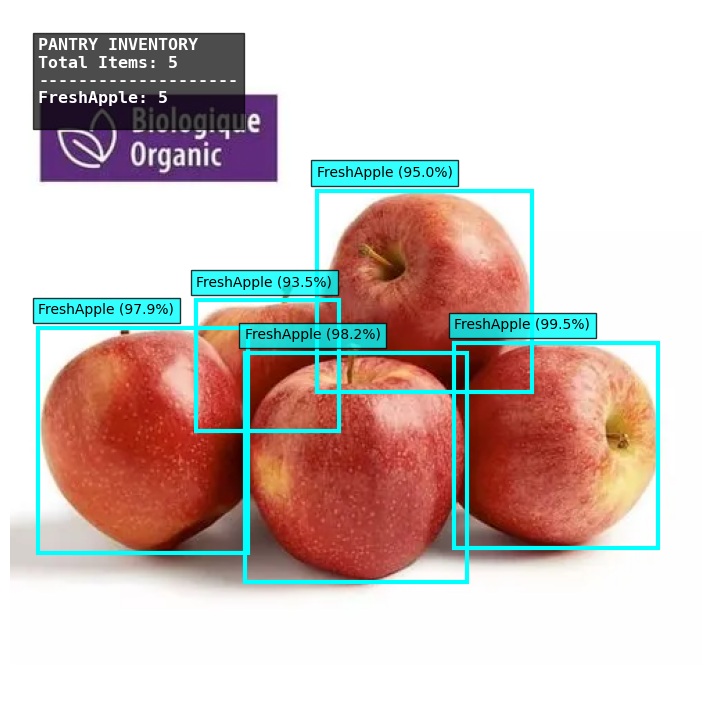

In [17]:
current_stock = run_pantry_inventory("apples.webp")


image 1/1 /Users/ngimagelusherpa/Documents/Image Processing and Computer Vision/final/rotton_apple.webp: 448x640 1 sandwich, 33.1ms
Speed: 1.0ms preprocess, 33.1ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


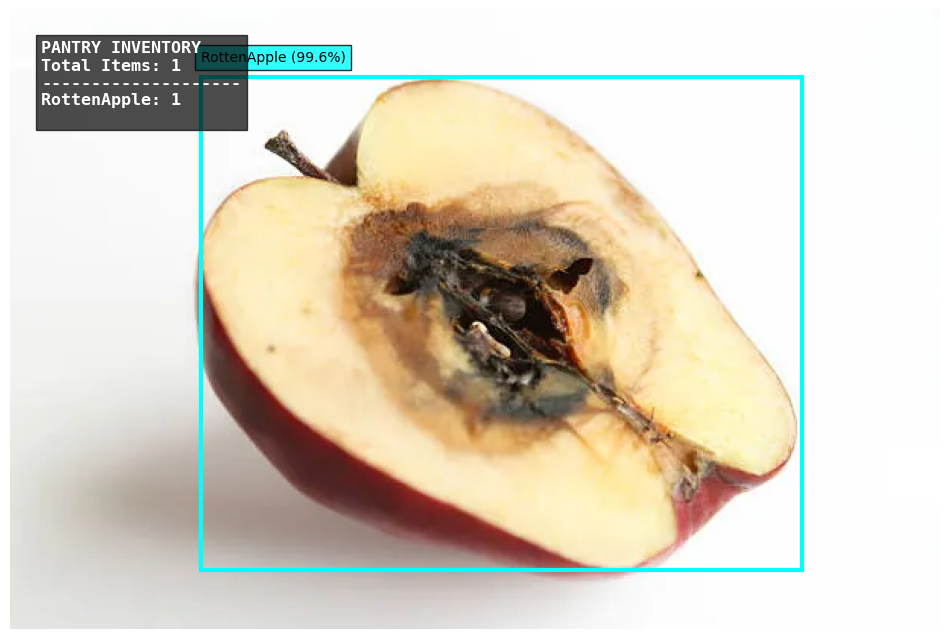

In [18]:
current_stock = run_pantry_inventory("rotton_apple.webp")

test_loader is now defined and ready!

--- CLIP-MLP Performance ---
              precision    recall  f1-score   support

  FreshApple       1.00      1.00      1.00       200
 RottenApple       1.00      1.00      1.00       200
 FreshBanana       1.00      1.00      1.00       200
RottenBanana       1.00      1.00      1.00       200
 FreshOrange       1.00      1.00      1.00       200
RottenOrange       1.00      1.00      1.00       200

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



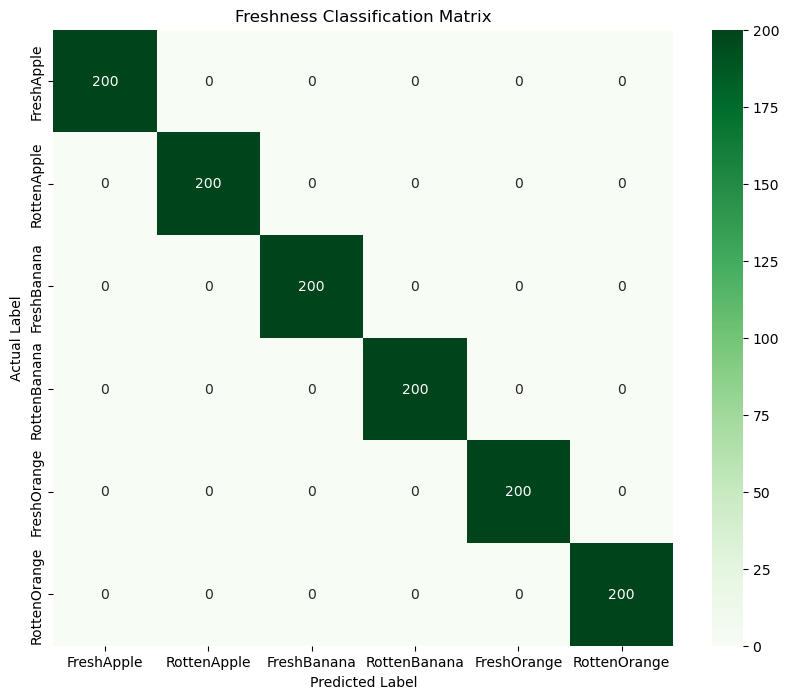

In [16]:
def eval_transform_fn(examples):
    inputs = processor(images=[img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    examples["pixel_values"] = inputs["pixel_values"]
    del examples["image"]
    return examples

# 2. Re-create the test_loader
if 'test' in remapped_dataset:
    test_ds = remapped_dataset['test'].with_transform(eval_transform_fn)
else:
    # If no test split, we'll use a portion of the train set or the full train set for now
    test_ds = remapped_dataset['train'].with_transform(eval_transform_fn)

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("test_loader is now defined and ready!")

def evaluate_specialist(loader, model, labels):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            inputs = batch["pixel_values"].to(device)
            targets = batch["label"].to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    # 1. Textual Metrics
    print("\n--- CLIP-MLP Performance ---")
    print(classification_report(all_labels, all_preds, target_names=labels))
    
    # 2. Visual Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Greens")
    plt.title("Freshness Classification Matrix")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run it:
evaluate_specialist(test_loader, model, labels)